# Разведочный анализ данных

Здесь собран нормальный стартовый разбор датасета: размер, пропуски, перекосы таргетов,
баланс классов, выбросы и признаки, которые либо почти ничего не добавляют, либо слишком
сильно дублируют друг друга.

In [10]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
from IPython.display import Image, display

from src.common.config import RESULTS_DIR
from src.eda import run_eda

## Запуск EDA

Скрипт ниже пересчитывает таблицы и графики в `results/eda`, а потом мы сразу смотрим
на них в ноутбуке.

In [3]:
eda = run_eda(top_k_correlations=20)

print(f"Датасет: {eda['dataset_path']}")
print(f"Размер таблицы: {eda['dataframe'].shape[0]} x {eda['dataframe'].shape[1]}")
print(f"Дескрипторов после фильтрации: {len(eda['feature_columns'])}")

Датасет: /Users/davidsukhashvili/Desktop/ML/MEPhi/ClassicMl/Neural Networks in Chemistry/data/data.xlsx
Размер таблицы: 1001 x 214
Дескрипторов после фильтрации: 210


## Первая проверка

Проверяем структуру данных

In [4]:
display(pd.DataFrame([eda['data_contract']]))
display(eda['dataframe'].head())

,dataset_path,checksum_sha256,rows,columns,feature_count,missing_values,duplicates,target_columns,thresholds,leakage_rules
0,data/data.xlsx,87fabec4e77159df7482ca480236712c031500d3935141...,1001,214,210,36,0,"[IC50, mM, CC50, mM, SI]","{'classification_ic50_gt_median': 46.585183, '...",[В признаки не попадают колонки с таргетами и ...


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0


## Таргеты

Для регрессии важнее всего форма распределений. Если хвост тяжёлый, линейные модели и метрики
ведут себя заметно стабильнее после `log1p`.

,target,count,mean,std,min,25%,50%,75%,max,skew,iqr
0,"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377,3.674929,212.460532
1,"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189,1.973333,794.090141
2,SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000,18.013202,15.133333


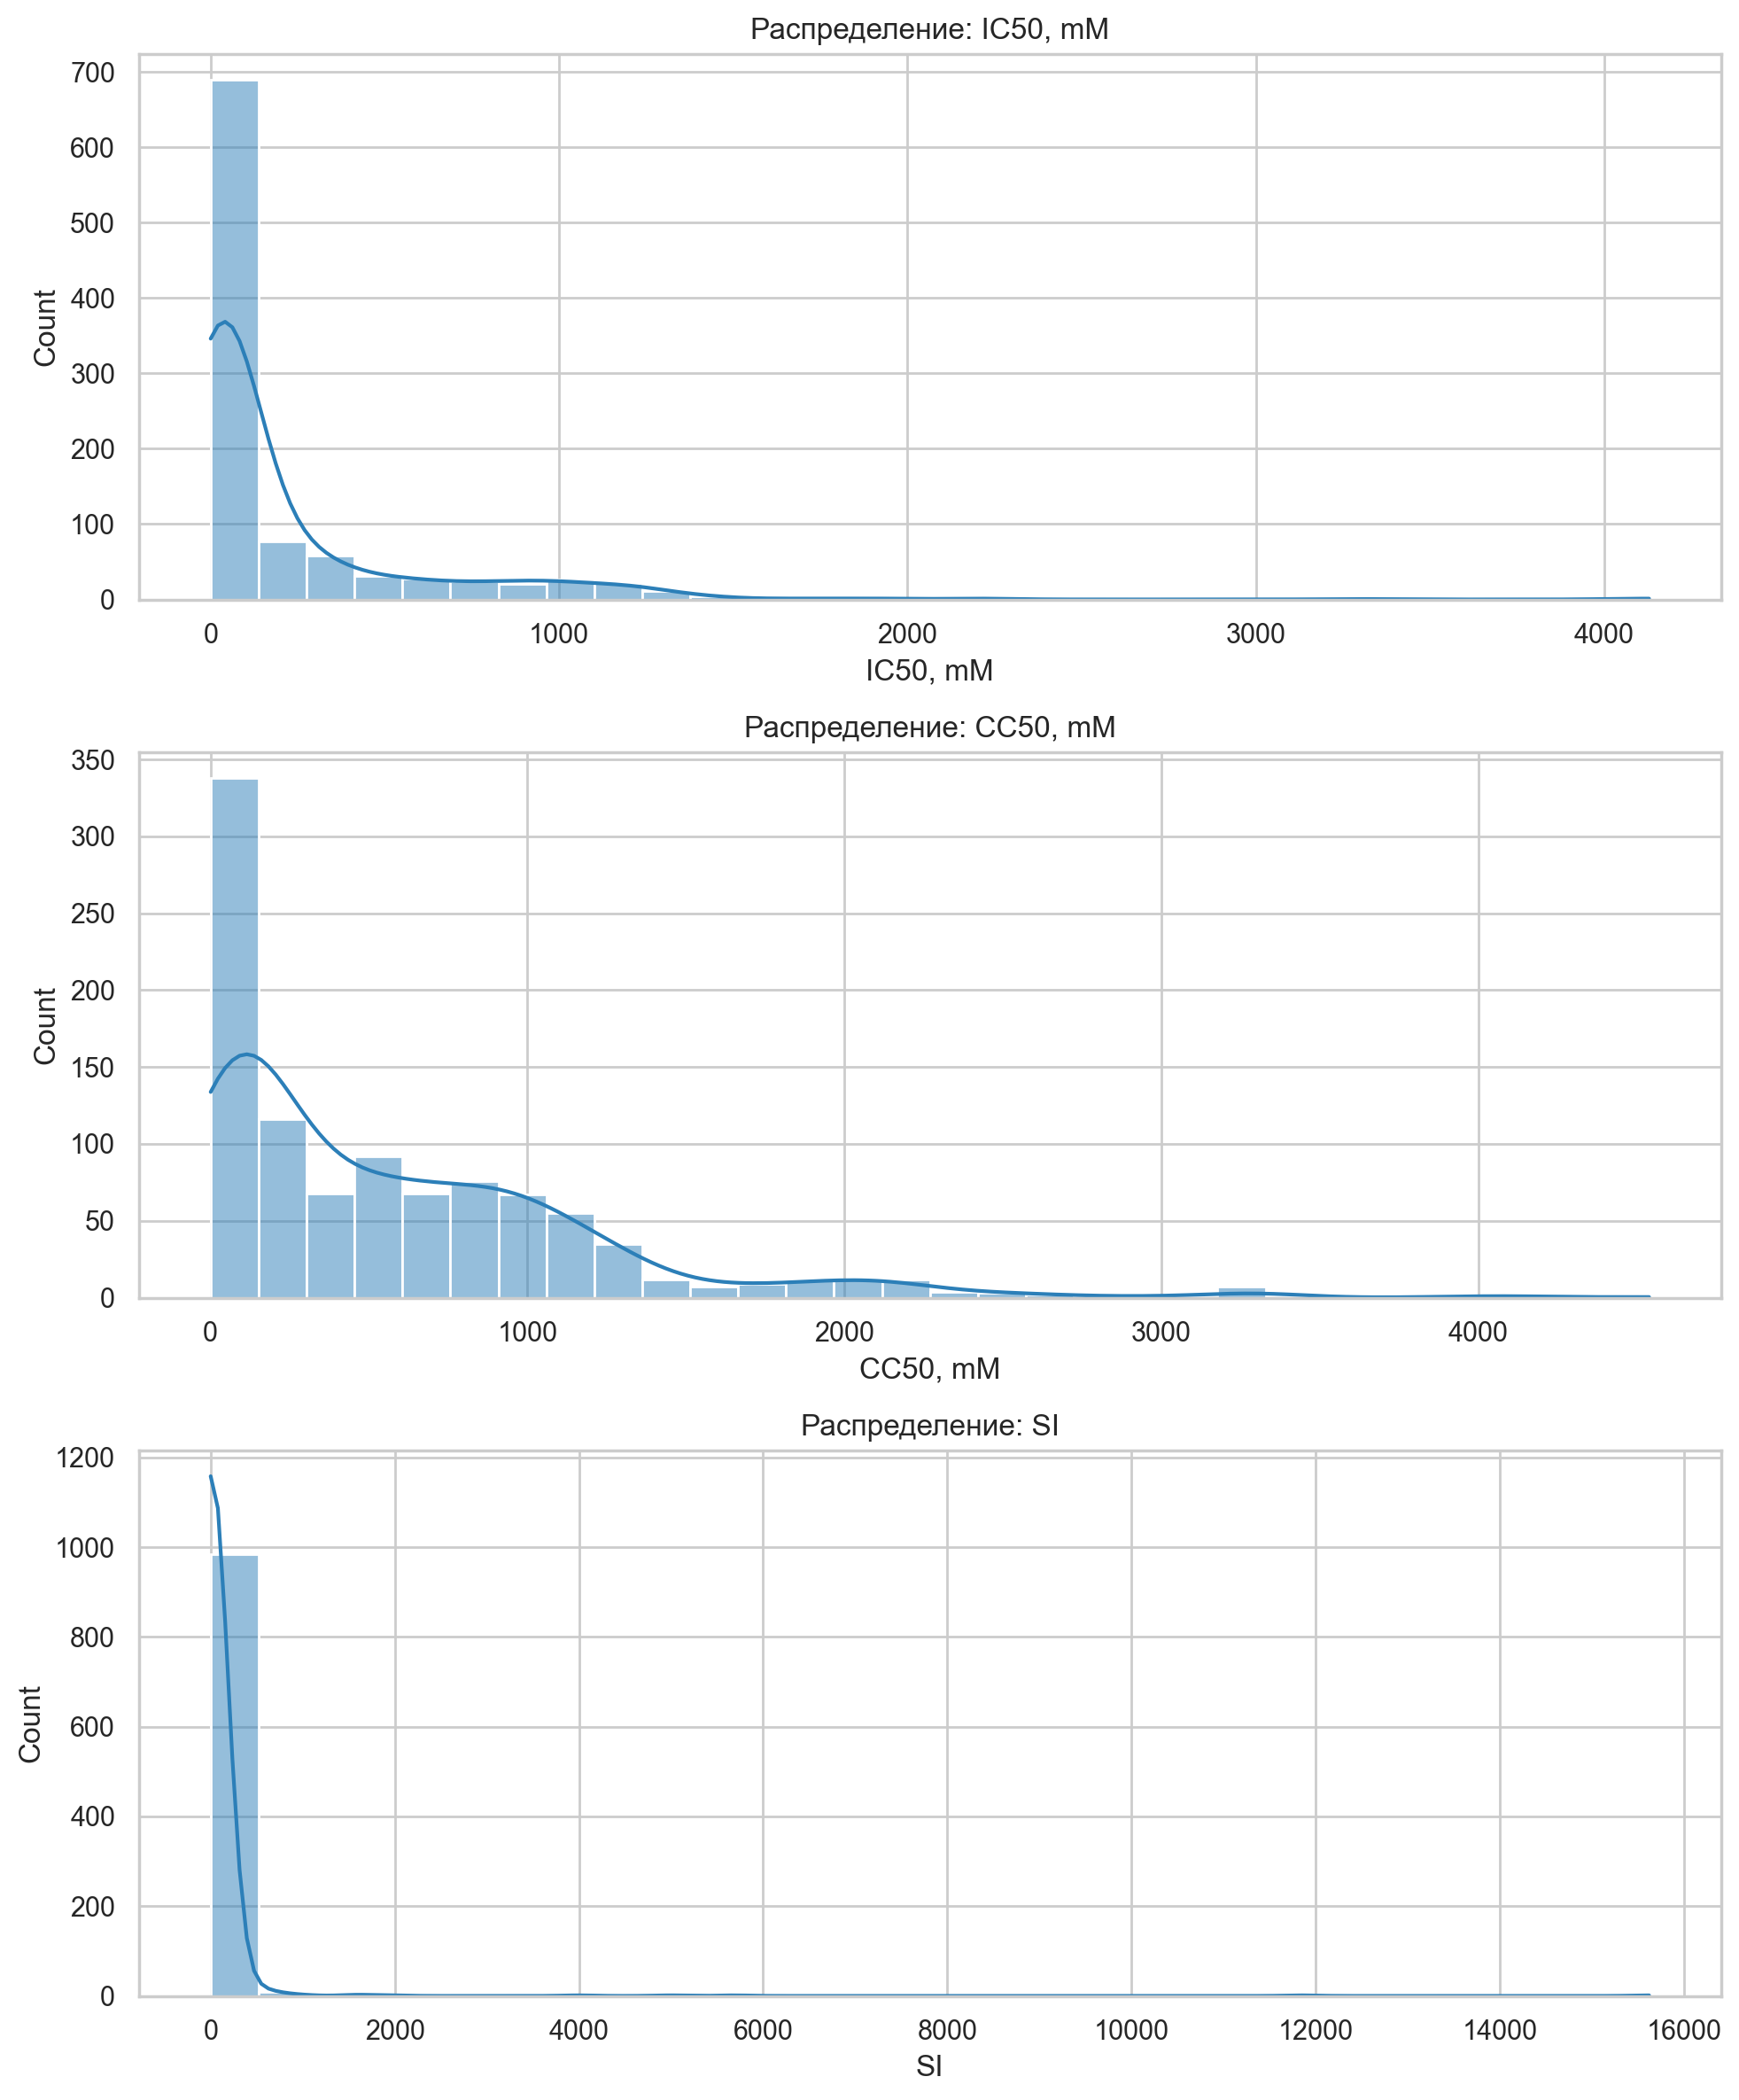

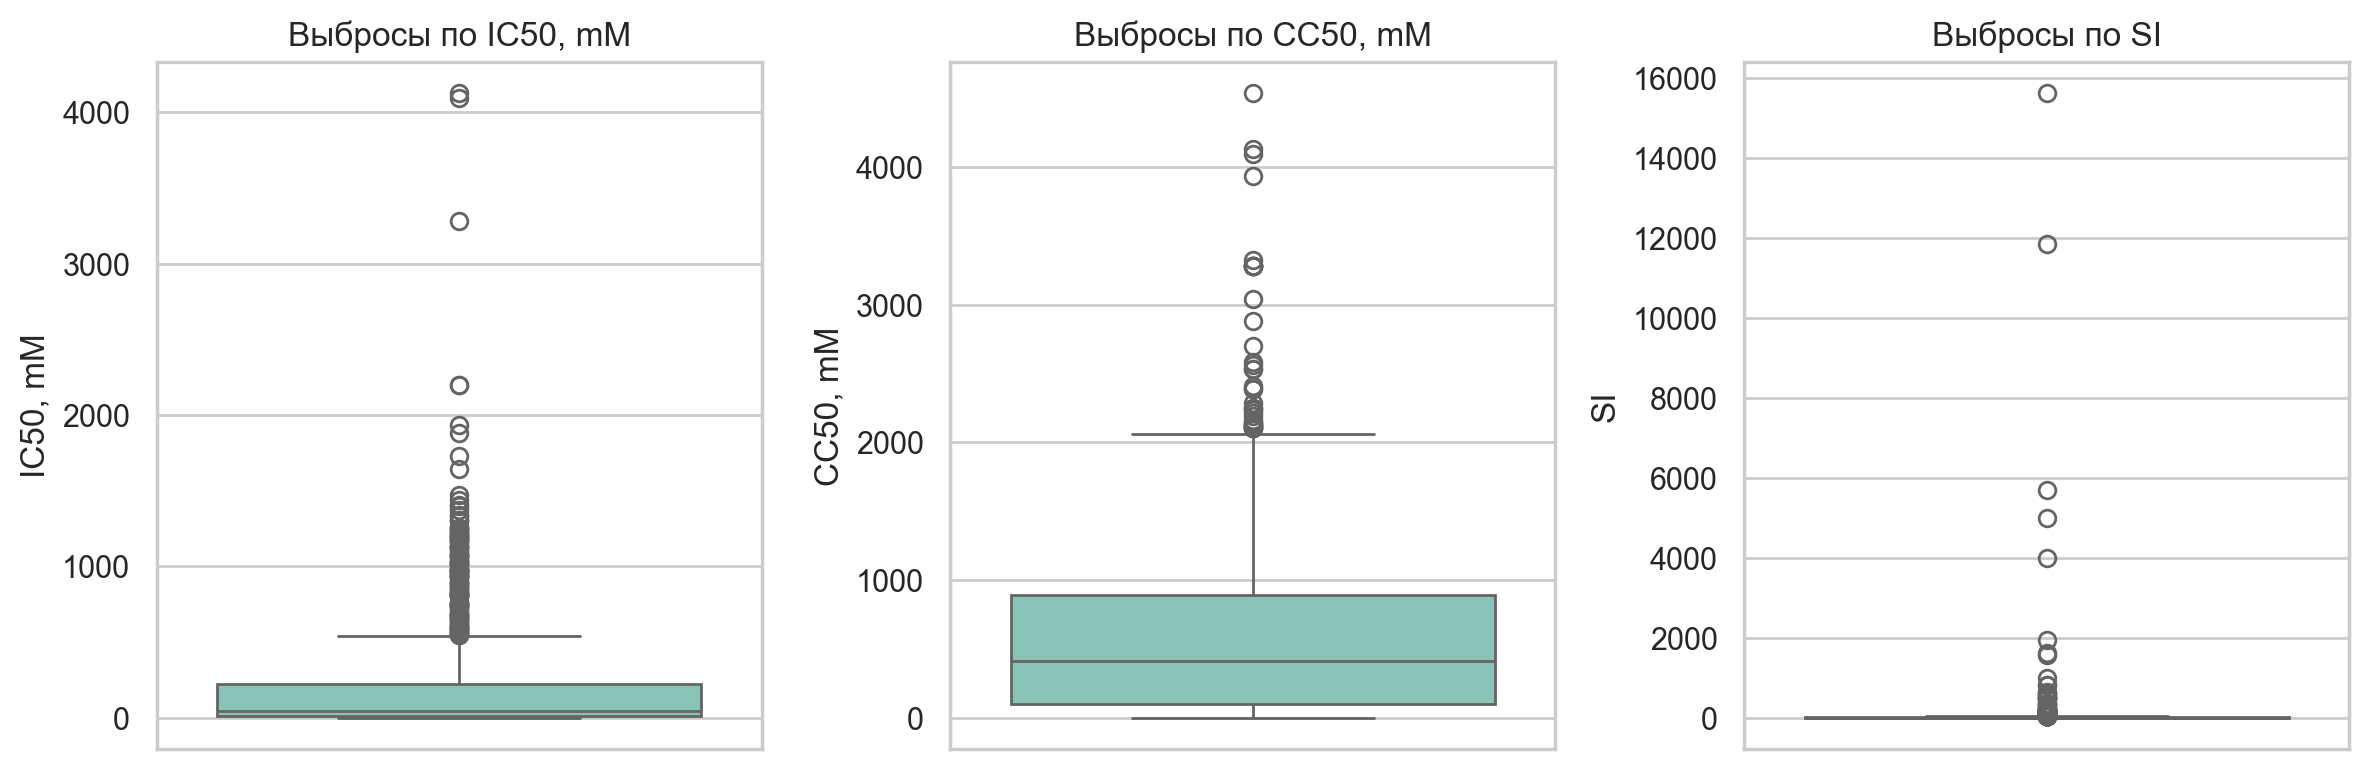

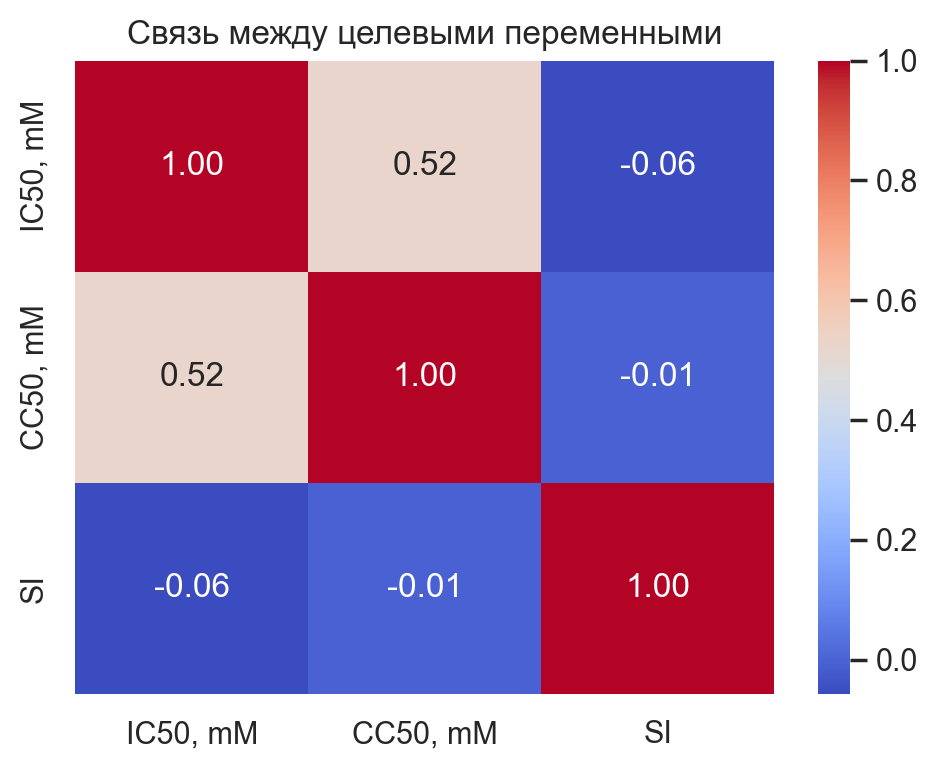

In [5]:
display(eda['target_summary'])
display(Image(filename=str(RESULTS_DIR / 'eda' / 'target_distributions.png')))
display(Image(filename=str(RESULTS_DIR / 'eda' / 'target_boxplots.png')))
display(Image(filename=str(RESULTS_DIR / 'eda' / 'target_correlations.png')))

## Пропуски, слабые признаки и дублирование

Тут полезно отделить две разные вещи:
1. Точечные пропуски, которые можно спокойно закрыть в sklearn-пайплайне.
2. Дескрипторы, которые почти не меняются или почти копируют друг друга.

,feature,missing_count,missing_share
0,MaxPartialCharge,3,0.002997
1,MinPartialCharge,3,0.002997
2,MaxAbsPartialCharge,3,0.002997
3,MinAbsPartialCharge,3,0.002997
4,BCUT2D_MWHI,3,0.002997
5,BCUT2D_MWLOW,3,0.002997
6,BCUT2D_CHGHI,3,0.002997
7,BCUT2D_CHGLO,3,0.002997
8,BCUT2D_LOGPHI,3,0.002997
9,BCUT2D_LOGPLOW,3,0.002997


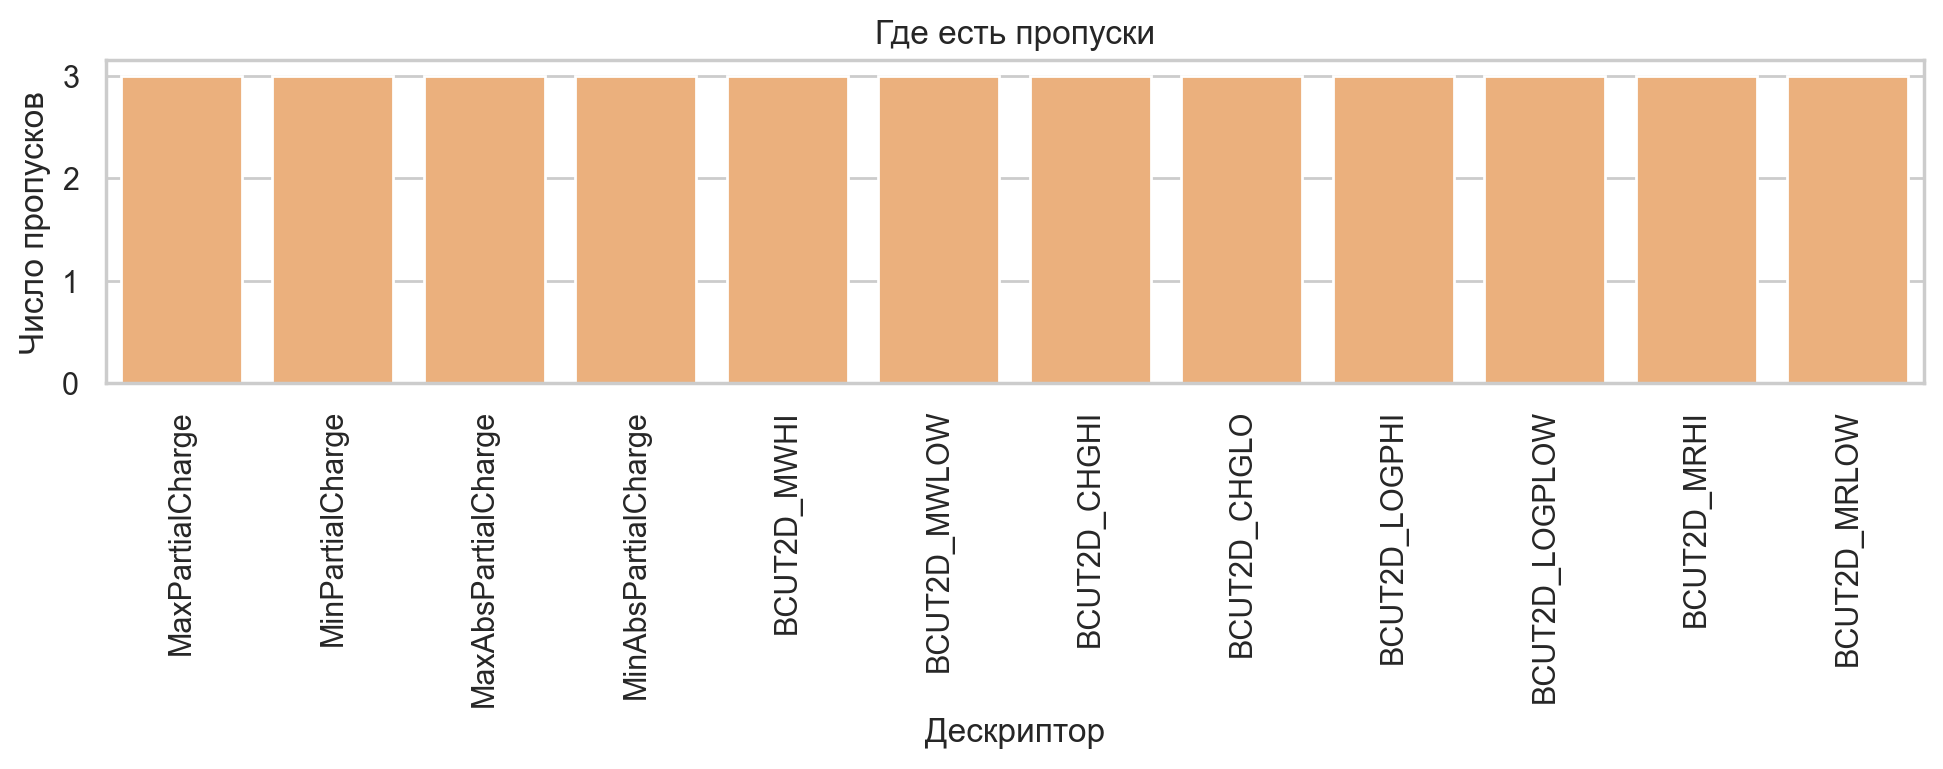

,feature,variance,unique_values,missing_count
0,NumRadicalElectrons,0.0,1,0
1,SMR_VSA8,0.0,1,0
2,SlogP_VSA9,0.0,1,0
3,fr_N_O,0.0,1,0
4,fr_SH,0.0,1,0
5,fr_azide,0.0,1,0
6,fr_barbitur,0.0,1,0
7,fr_benzodiazepine,0.0,1,0
8,fr_diazo,0.0,1,0
9,fr_dihydropyridine,0.0,1,0


,feature_left,feature_right,abs_correlation
0,MaxAbsEStateIndex,MaxEStateIndex,1.000000
1,NumAromaticCarbocycles,fr_benzene,1.000000
2,fr_COO,fr_COO2,1.000000
3,fr_Ar_NH,fr_Nhpyrrole,1.000000
4,fr_phenol,fr_phenol_noOrthoHbond,1.000000
5,MolWt,ExactMolWt,0.999999
6,Chi1,HeavyAtomCount,0.998742
7,MolWt,HeavyAtomMolWt,0.996850
8,HeavyAtomMolWt,ExactMolWt,0.996821
9,Chi0,HeavyAtomCount,0.995957


In [6]:
display(eda['missing_summary'])
if not eda['missing_summary'].empty:
    display(Image(filename=str(RESULTS_DIR / 'eda' / 'missing_values.png')))

display(eda['low_variance_summary'].head(15))
display(eda['high_correlation_pairs'].head(15))

## Что происходит в классификации

Пороговые задачи по медиане должны быть хорошо сбалансированы. 
Это удобная постановка для сравнения моделей. 
`SI > 8` заметно тяжелее: там положительный класс встречается реже.

,task_name,target_column,threshold,label,count,share
0,classification_ic50_gt_median,"IC50, mM",46.585183,0,500,0.499500
1,classification_ic50_gt_median,"IC50, mM",46.585183,1,501,0.500500
2,classification_cc50_gt_median,"CC50, mM",411.039342,0,500,0.499500
3,classification_cc50_gt_median,"CC50, mM",411.039342,1,501,0.500500
4,classification_si_gt_median,SI,3.846154,0,501,0.500500
5,classification_si_gt_median,SI,3.846154,1,500,0.499500
6,classification_si_gt_8,SI,8.000000,0,644,0.643357
7,classification_si_gt_8,SI,8.000000,1,357,0.356643


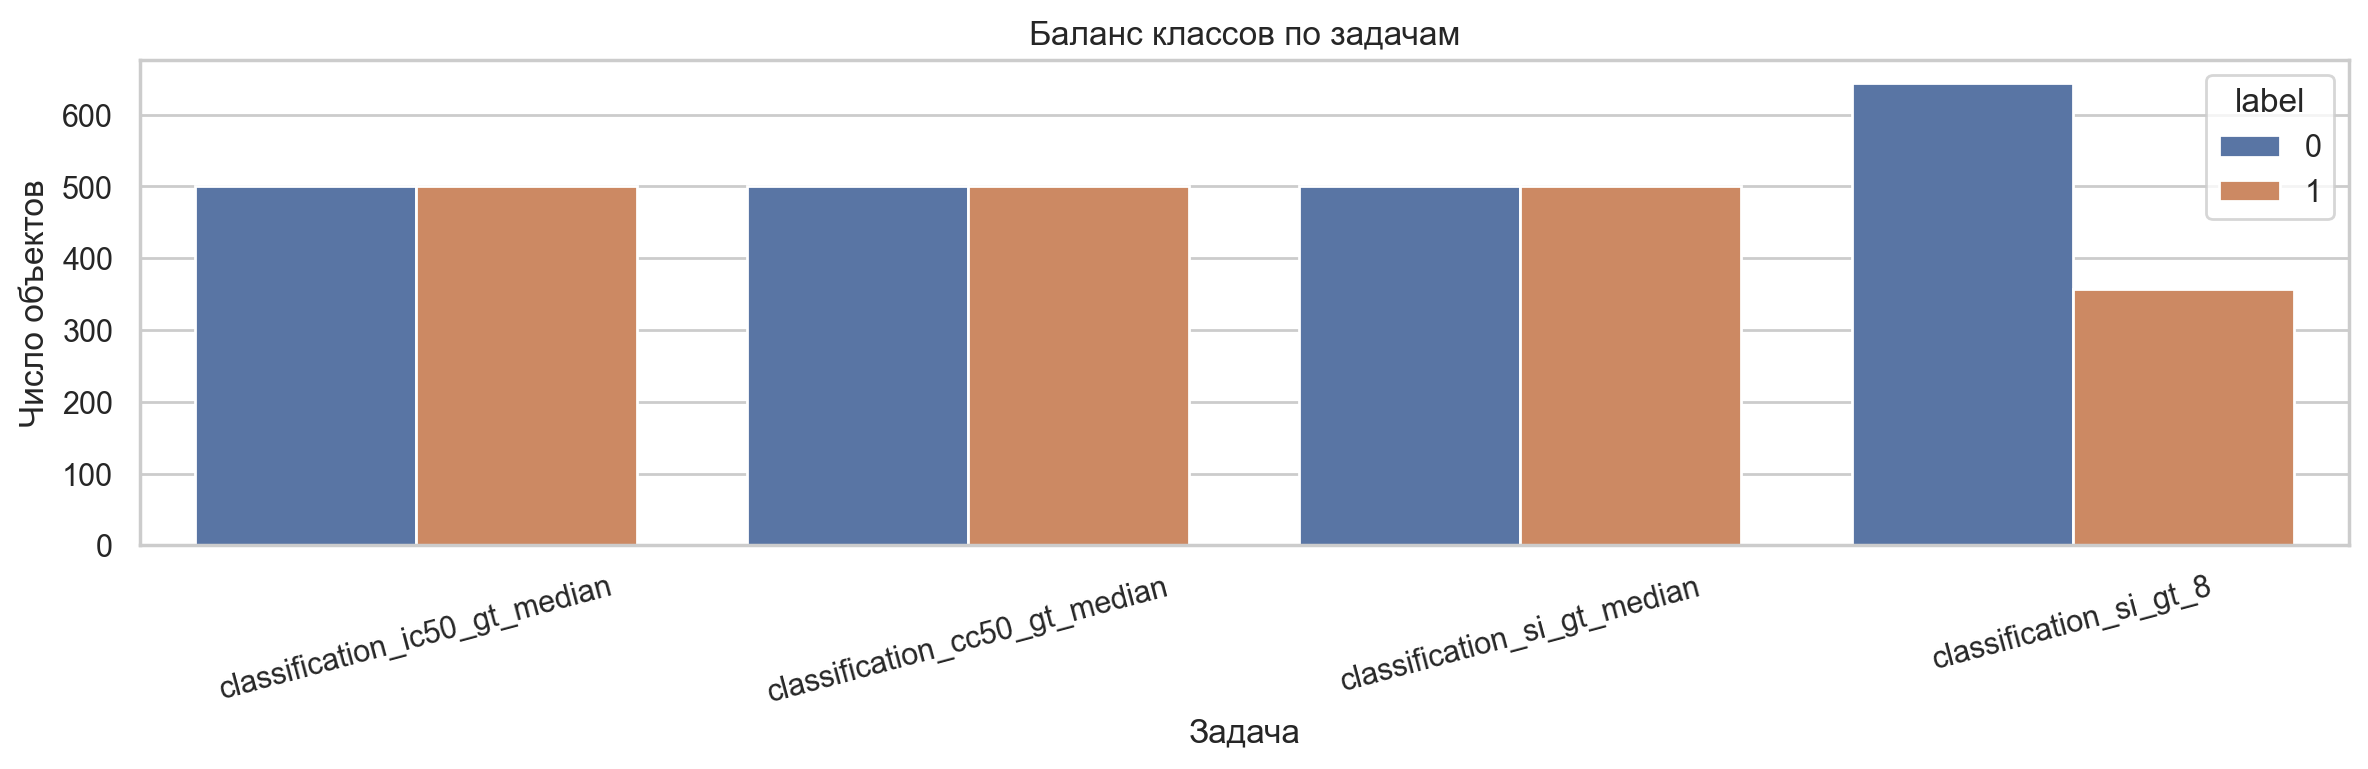

In [7]:
display(eda['class_balance'])
display(Image(filename=str(RESULTS_DIR / 'eda' / 'class_balance.png')))

## Какие дескрипторы хотя бы линейно зацепляются за таргеты

Это не значит, что модель должна быть линейной. Но такой срез быстро показывает,
где сигнал заметнее, а где его почти нет.

,target_column,feature,correlation,abs_correlation
0,"IC50, mM",VSA_EState4,-0.274203,0.274203
1,"IC50, mM",Chi2n,-0.257058,0.257058
2,"IC50, mM",PEOE_VSA7,-0.255988,0.255988
3,"IC50, mM",Chi2v,-0.249164,0.249164
4,"IC50, mM",fr_Ar_NH,0.245511,0.245511
5,"IC50, mM",fr_Nhpyrrole,0.245511,0.245511
6,"IC50, mM",Chi4v,-0.243600,0.243600
7,"IC50, mM",Chi4n,-0.243497,0.243497
8,"IC50, mM",Chi3n,-0.239741,0.239741
9,"IC50, mM",Chi3v,-0.237759,0.237759


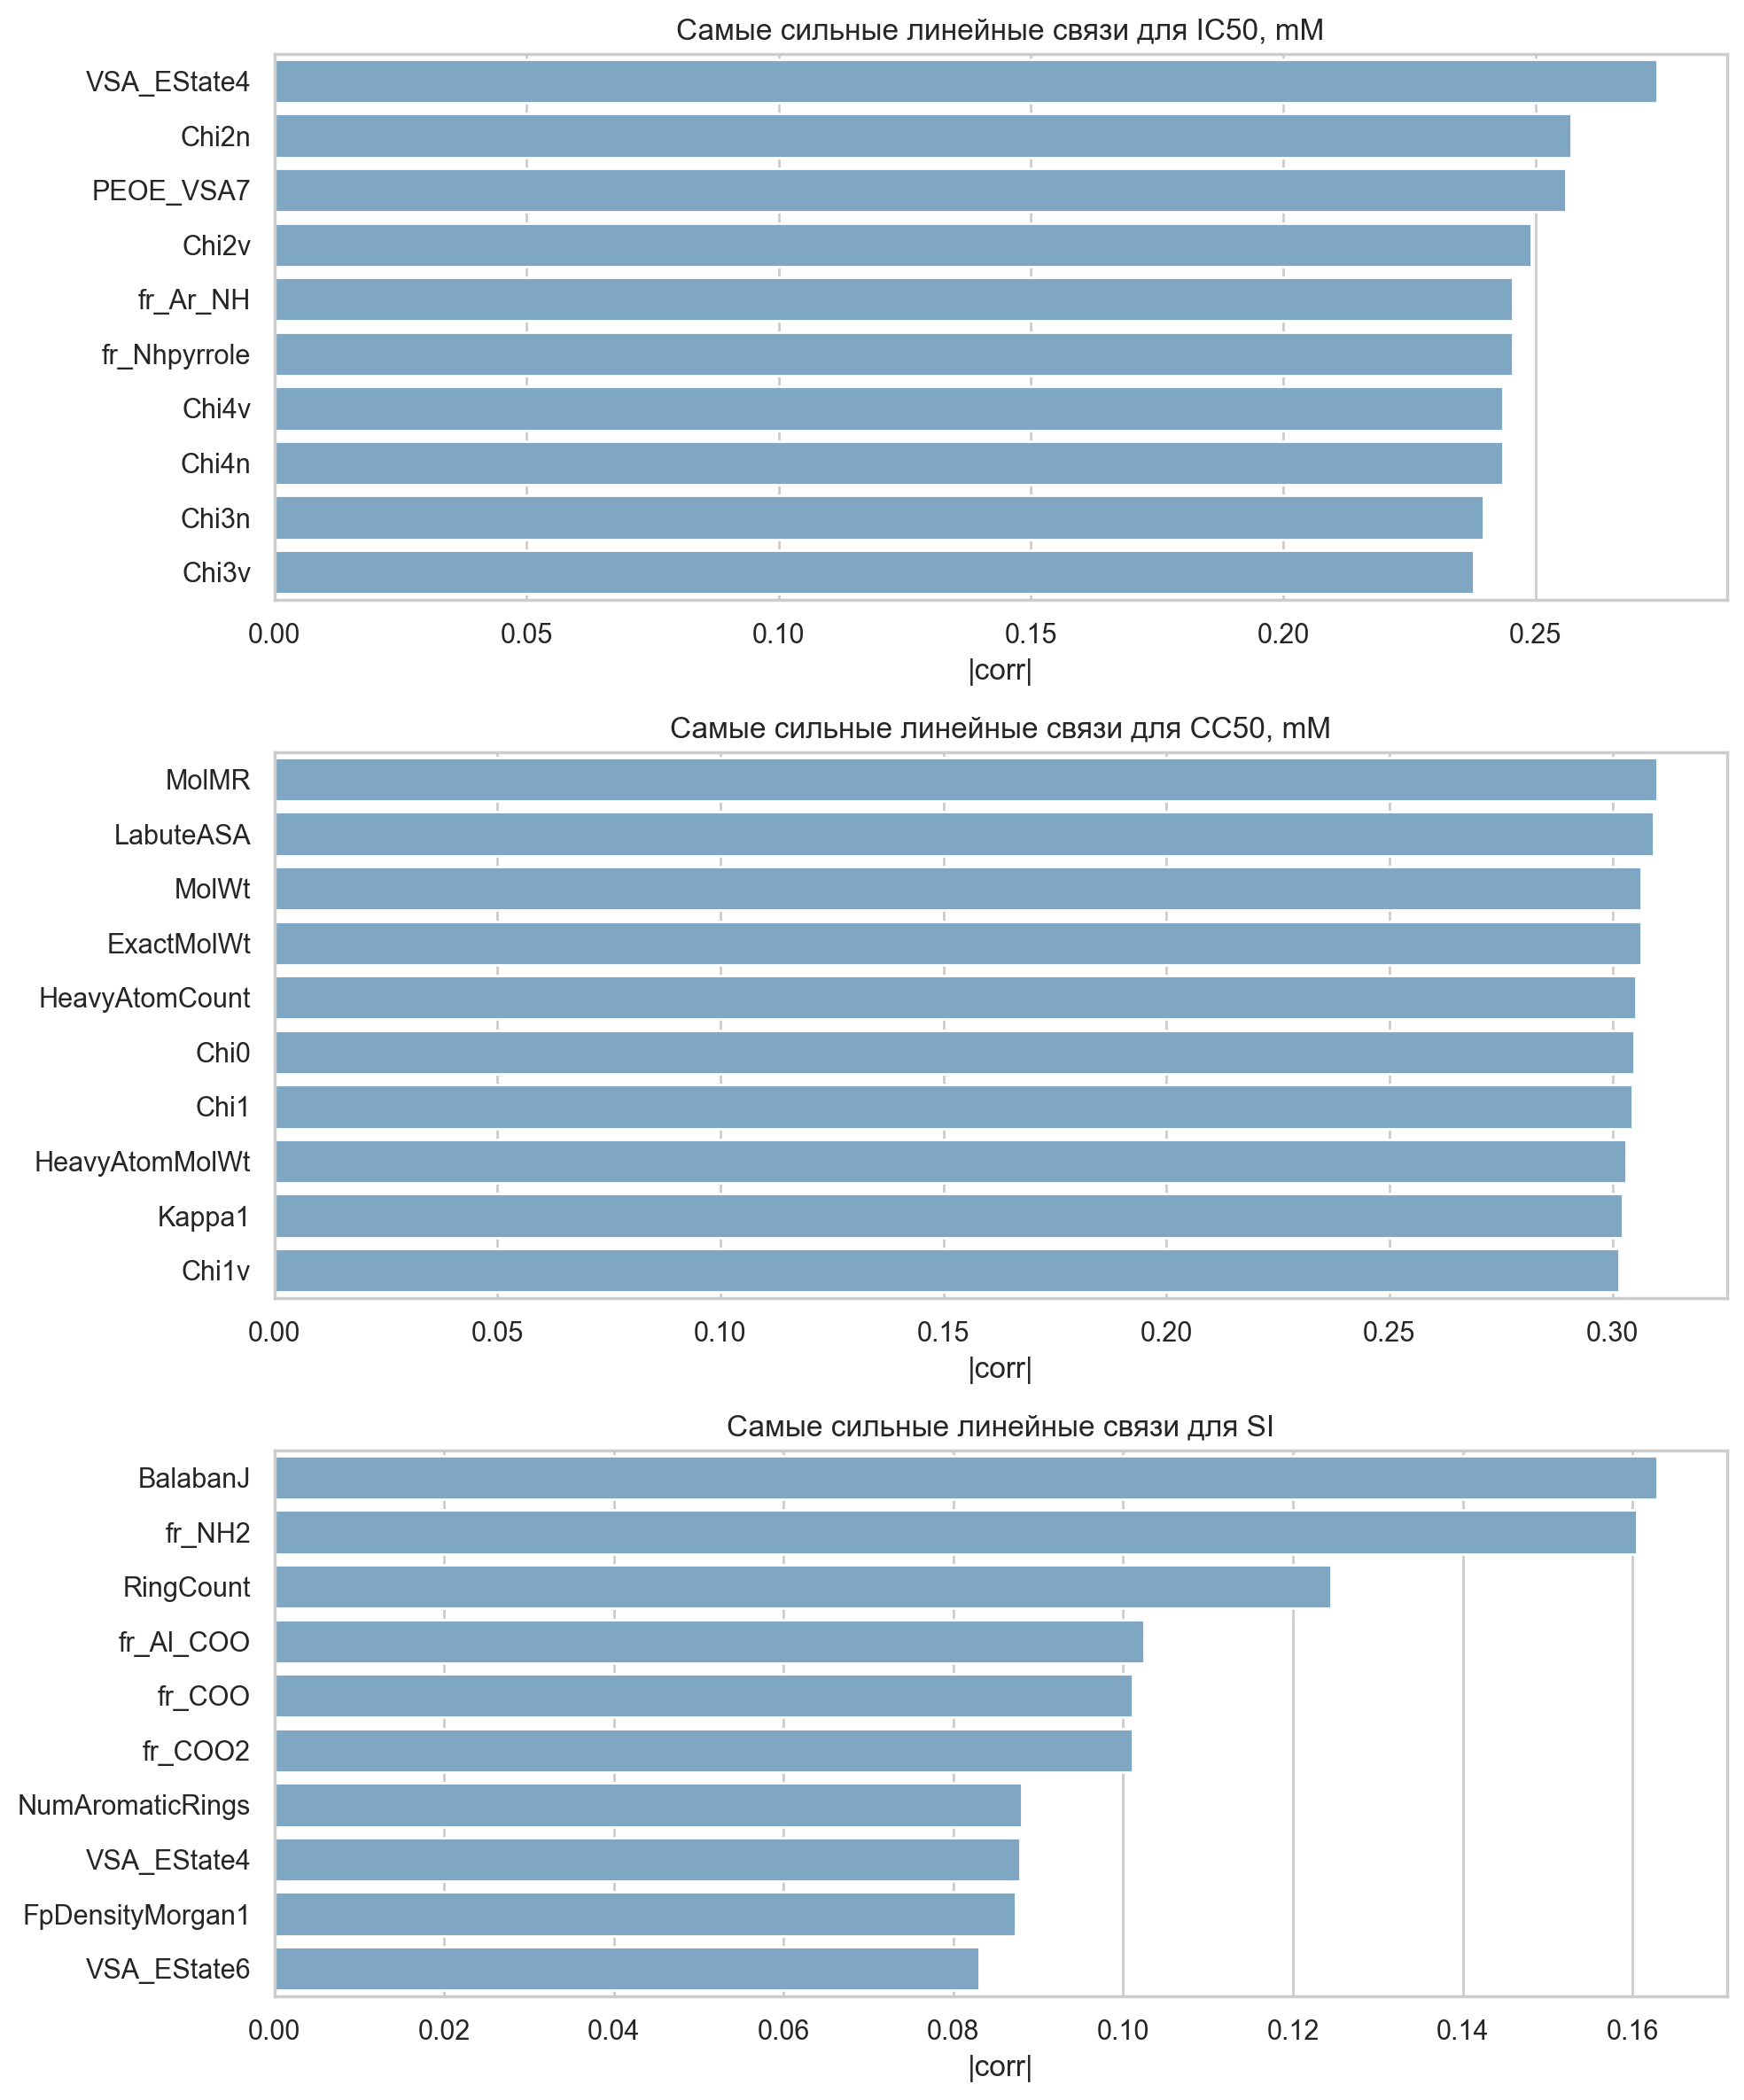

In [8]:
display(eda['target_correlations'])
display(Image(filename=str(RESULTS_DIR / 'eda' / 'top_target_correlations.png')))

## Короткие выводы

In [11]:
target_summary = eda['target_summary'].set_index('target')
outliers = eda['outlier_summary'].set_index('target')
balance = eda['class_balance'].pivot(index='task_name', columns='label', values='count')
strong_pairs = len(eda['high_correlation_pairs'])
quasi_constant = int((eda['low_variance_summary']['unique_values'] <= 2).sum())

print(
    f"IC50, CC50 и особенно SI имеют тяжёлые правые хвосты: skew = "
    f"{target_summary.loc['IC50, mM', 'skew']:.2f}, "
    f"{target_summary.loc['CC50, mM', 'skew']:.2f}, "
    f"{target_summary.loc['SI', 'skew']:.2f}."
)
print(
    f"По IQR-критерию выбросов у IC50={int(outliers.loc['IC50, mM', 'outlier_count'])}, "
    f"CC50={int(outliers.loc['CC50, mM', 'outlier_count'])}, "
    f"SI={int(outliers.loc['SI', 'outlier_count'])}."
)
print(
    f"Пропуски точечные: {int(eda['missing_summary']['missing_count'].sum()) if not eda['missing_summary'].empty else 0} значений "
    f"в {len(eda['missing_summary'])} дескрипторах. Их нет смысла править вручную вне пайплайна."
)
print(
    f"Квазиконстантных признаков: {quasi_constant}. Сильно коррелирующих пар (|corr| >= 0.95): {strong_pairs}."
)
print(
    'По медианным порогам классы почти ровные, а задача SI > 8 заметно дисбаланснее: '
    f"{int(balance.loc['classification_si_gt_8', 0])} против {int(balance.loc['classification_si_gt_8', 1])}."
)
print(
    'Для SI линейный сигнал ощутимо слабее, чем для IC50 и CC50. Поэтому там особенно важно '
    'сравнивать несколько моделей и отдельно смотреть прямой и косвенный сценарии.'
)

IC50, CC50 и особенно SI имеют тяжёлые правые хвосты: skew = 3.67, 1.97, 18.01.
По IQR-критерию выбросов у IC50=147, CC50=39, SI=125.
Пропуски точечные: 36 значений в 12 дескрипторах. Их нет смысла править вручную вне пайплайна.
Квазиконстантных признаков: 48. Сильно коррелирующих пар (|corr| >= 0.95): 91.
По медианным порогам классы почти ровные, а задача SI > 8 заметно дисбаланснее: 644 против 357.
Для SI линейный сигнал ощутимо слабее, чем для IC50 и CC50. Поэтому там особенно важно сравнивать несколько моделей и отдельно смотреть прямой и косвенный сценарии.
